# AOI: Purchase, NY

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Train AI Model for Building Detection
- This task is called 'semantic segmentation' in AI context
- Use models from `segmentation-models-pytorch` library (https://smp.readthedocs.io)

## Setup & Import
GPU & GeoAI wrapper tool is require

In [2]:
# GPU is required - T4 GPU will be used
!nvidia-smi

Mon May  4 20:57:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# GeoAI = wrapper tool
%pip install geoai-py --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/

In [4]:
import geoai
geoai.__version__

'0.37.2'

## Data Import

In [5]:
train_raster_path = "/content/merged_clipped-1.tif"
train_vector_path = "/content/filename.geojson"

### Create training data (image chips)

In [6]:
out_folder = "buildings"
tiles = geoai.export_geotiff_tiles(
    in_raster = train_raster_path, # satellite
    out_folder = out_folder, # folder containing image chips
    in_class_data = train_vector_path, # label
    tile_size = 512, # size of chips (width, height in px)
    stride = 256,
    buffer_radius = 0
)

Generated: 4, With features: 4: 100%|██████████| 4/4 [00:00<00:00, 10.89it/s]


## DeepLabV3

### Model Training:

In [7]:
# function train_segmentation_model is required to train segmentation model
geoai.train_segmentation_model(
    images_dir = f"{out_folder}/images", # location for input image data
    labels_dir = f"{out_folder}/labels", # location for input label data
    output_dir = f"{out_folder}/deeplabv3models", # location for storing trained model's spec/log
    architecture = "deeplabv3", # segmentation model
    encodder_name = "resnet34", # encoder model,
    encoder_weights = "imagenet",
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    batch_size = 8,
    num_epochs = 20,
    learning_rate = 0.001,
    val_split = 0.2,
    verbose = True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

### Inference (Prediction)

In [8]:
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/deeplabv3models/best_model.pth"

In [9]:
#DeepLabV3 Training
geoai.semantic_segmentation(
    input_path = train_raster_path,
    output_path = masks_path,
    model_path = model_path,
    architecture = "deeplabv3", # segmentation model
    encodder_name = "resnet34", # encoder model,

    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    window_size = 512,
    stride = 256,
    batch_size = 4,
)

9it [00:00, 12.88it/s]


In [10]:
# Visualize
geoai.view_raster(masks_path, basemap=train_raster_path, backend="ipyleaflet")

Map(center=[41.0376135, -73.73818800000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

### Vectorize masks (output labels)

In [13]:
import os
output_vector_path = "naip_test_semantic_prediction.geojson"

# Check if the mask file exists and attempt orthogonalization
if os.path.exists(masks_path):
    try:
        gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2)
        display(gdf)
    except ValueError as e:
        print(f"Could not vectorize: {e}. This usually means no buildings were detected in the mask.")
else:
    print("Mask file not found. Please run the inference cell again.")

Converting features: 100%|██████████| 1/1 [00:00<00:00, 8050.49shape/s]

Could not vectorize: Assigning CRS to a GeoDataFrame without a geometry column is not supported. Supply geometry using the 'geometry=' keyword argument, or by providing a DataFrame with column name 'geometry'. This usually means no buildings were detected in the mask.


### Performance Analysis

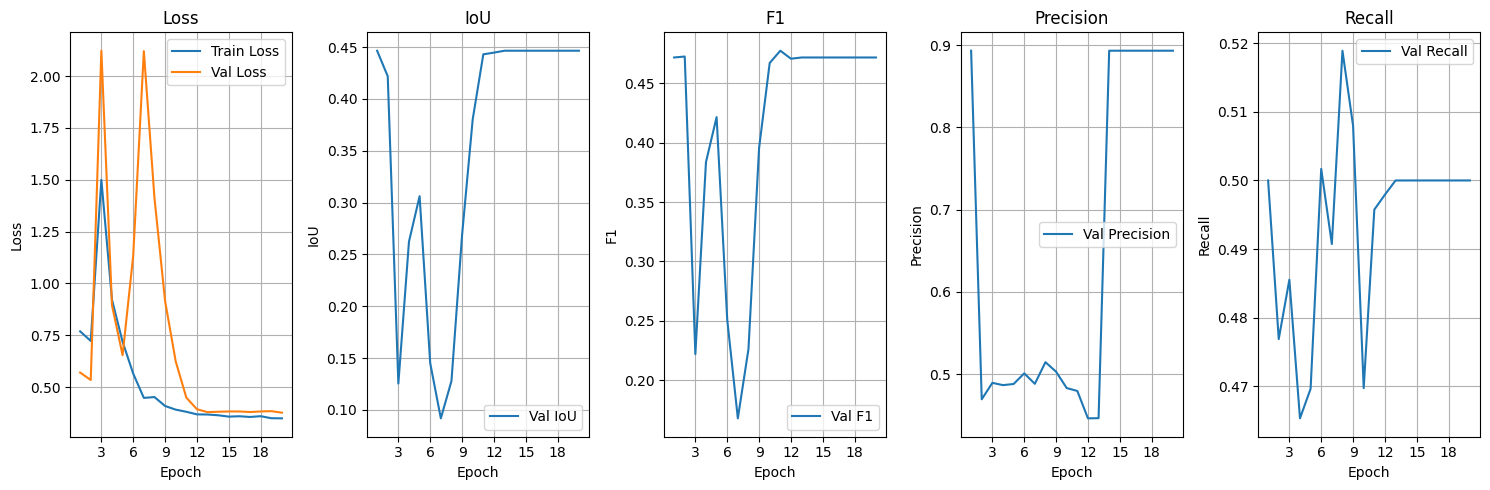

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.768693,0.569897,0.446577,0.471781,0.893154,0.500000
1,2,0.722402,0.533858,0.421926,0.472582,0.469514,0.476901
2,3,1.499565,2.122609,0.125355,0.221967,0.489511,0.485543
3,4,0.921504,0.894574,0.262357,0.383738,0.486743,0.465355
4,5,0.718012,0.653724,0.306163,0.421563,0.488125,0.469666
5,6,0.564594,1.134604,0.144987,0.251087,0.501050,0.501687
6,7,0.447596,2.120601,0.091773,0.167898,0.488361,0.490742
7,8,0.451584,1.412270,0.127799,0.226170,0.514635,0.518896
8,9,0.408588,0.914957,0.268750,0.395537,0.503057,0.507954
9,10,0.390905,0.623944,0.380349,0.467175,0.483182,0.469754


In [15]:
geoai.plot_performance_metrics (
    history_path = f"{out_folder}/deeplabv3models/training_history.pth",
    figsize=(15, 5),
    verbose = True
)